In [1]:
import sys

sys.dont_write_bytecode = True #不生成pychache文件，要放在导入模块前才生效

import os

# import soundfile

fs = 16000

In [3]:
%run ../../src/data/Pretraining_sub_control_filters.py

0
/home/rkobayashi/anc/GFANC-custom


-21.935138432851822


[========================================================================] 100%


In [2]:
%run ../../src/data/Pretraining_sub_control_filters.py

-25
/home/rkobayashi/anc/GFANC-custom


-21.89210380728238


[========================================================================] 100%


In [4]:
%run ../../src/data/Pretraining_sub_control_filters.py

5
/home/rkobayashi/anc/GFANC-custom


0.134744645032223


[========================================================================] 100%


In [2]:
run Pretraining_sub_control_filters.py

-25
-23.140564


/home/rkobayashi/anc/GFANC-Generative-fixed-filter-active-noise-control/Hard_Label/1.Labeling_Dataset_Code/Pretraining_sub_control_filters.py:68: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  print(10*np.log10(np.mean(np.square(np.array(Erro)))/np.mean(np.square(Dis.numpy()))))


In [ ]:
snrs = [50, 25, 20, 10, 0, -10,]

In [ ]:
"""
# Pretraining a control filter with 20Hz-7980Hz and divide it into 15 sub filters

%run Pretraining_sub_control_filters.py
"""

'\n# Pretraining a control filter with 20Hz-7980Hz and divide it into 15 sub filters\n\n%run Pretraining_sub_control_filters.py\n'

In [ ]:
%run Pretraining_sub_control_filters.py

FileNotFoundError: [Errno 2] No such file or directory: 'Pz and Sz/Secondary_path_1_delay_nonesamples/Primary_path.mat'

In [ ]:

# Generate synthesized noise dataset: 80000 random noises

from DataSet_construction import Generating_Synthetic_NoiseDataset

Folder_name_list_of_data_set =['Dataset/Synthesized_Dataset/Training_data', 'Dataset/Synthesized_Dataset/Validate_data', 'Dataset/Synthesized_Dataset/Testing_data']
N_sample_list =[80000, 2000, 2000]
for Folder_name_of_data_set, N_sample in zip(Folder_name_list_of_data_set,N_sample_list):
    if not os.path.exists(Folder_name_of_data_set):
        Generating_Synthetic_NoiseDataset(N_sample=N_sample, Folder_name=Folder_name_of_data_set)
    else:
        print(Folder_name_of_data_set + 'exists !!!')
        
# generated 80000 training data, 2000 Validate data, 2000 test data. Each folder has a csv file.



KeyboardInterrupt: 

folder exists
=====================Start labeling ============================
The total file numer is 80000


<<===This program used cuda====>>


[========================================================================] 100%


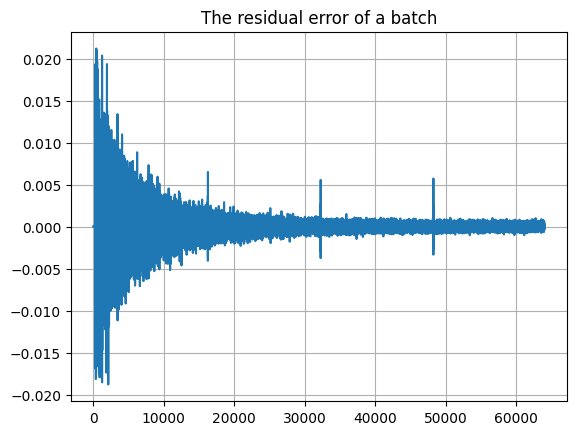

[========================================================================] 100%


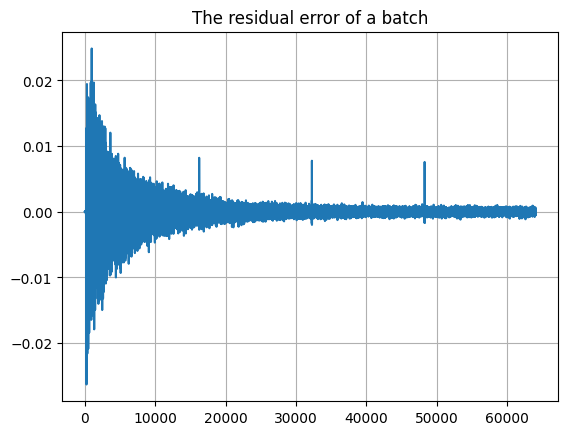

[========================================================================] 100%


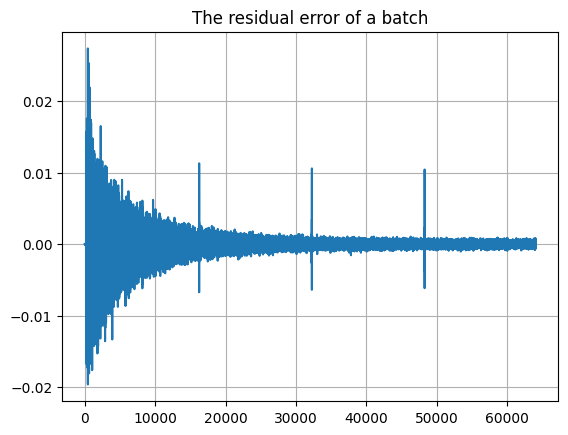

[========================================================================] 100%


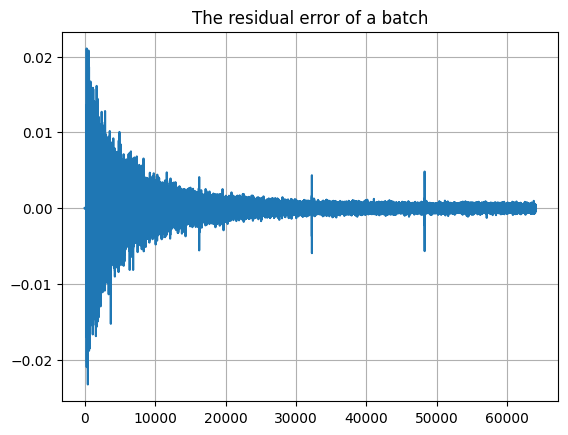

[========================================================================] 100%


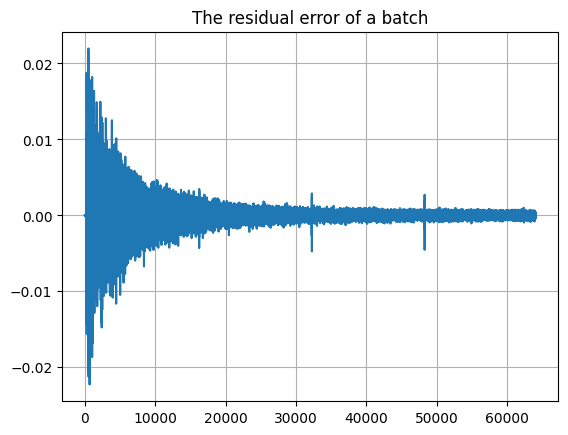

[========================================================================] 100%


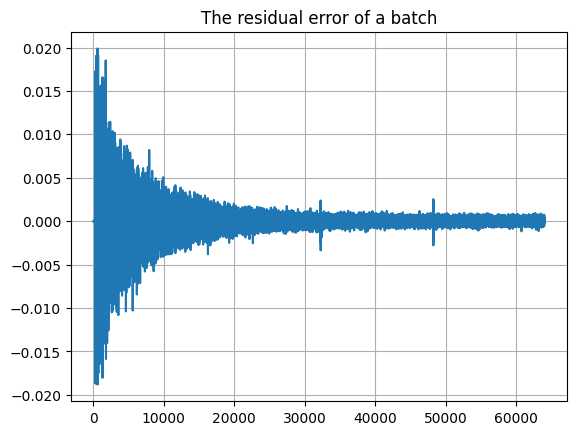

[========================================================================] 100%


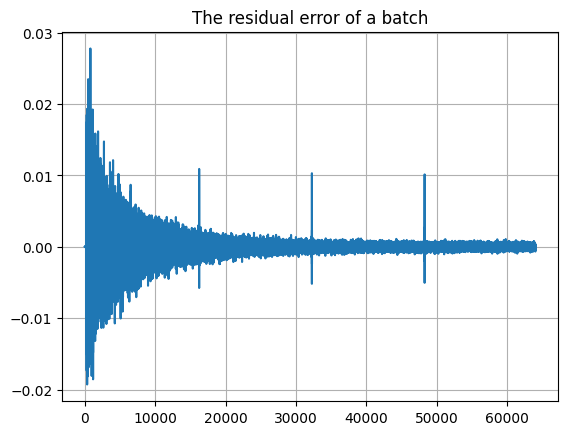

[========================================================================] 100%


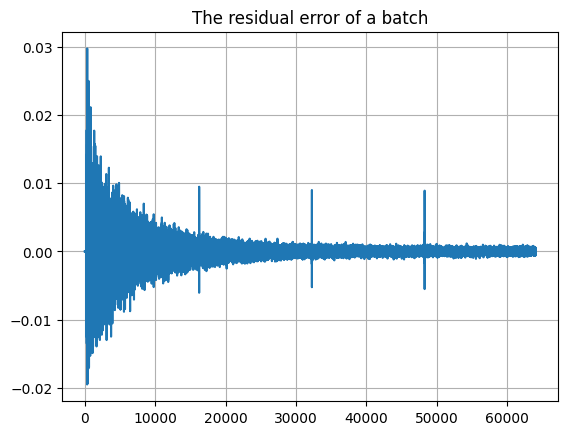

[========================================================================] 100%


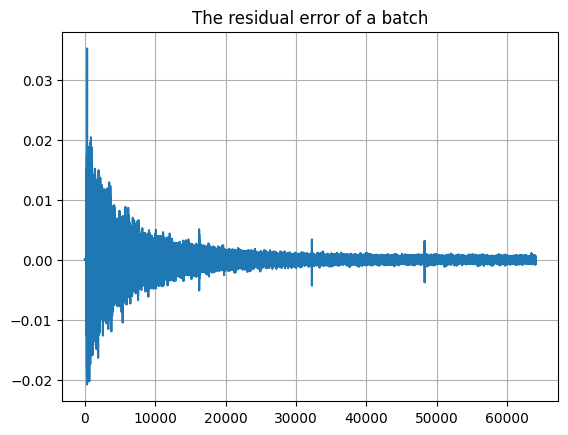

[========================================================================] 100%


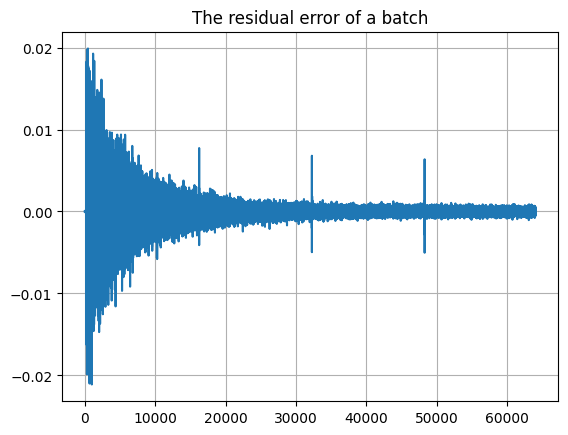

[========================================================================] 100%


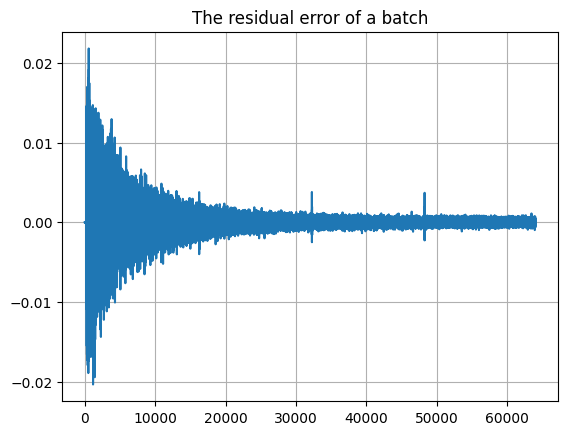

[========================================================================] 100%


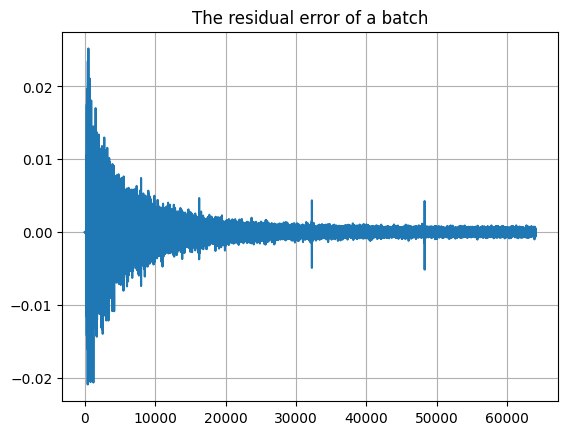

[========================================================================] 100%


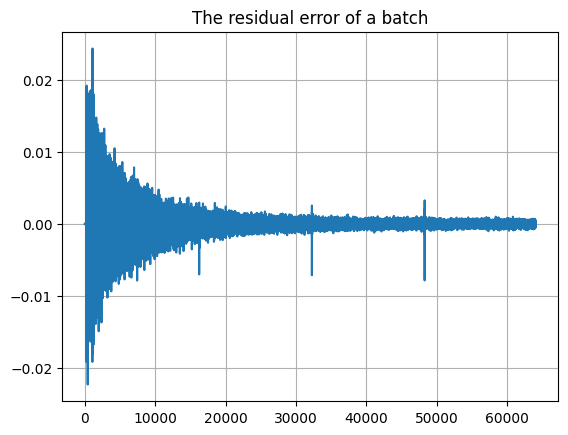

[========================================================================] 100%


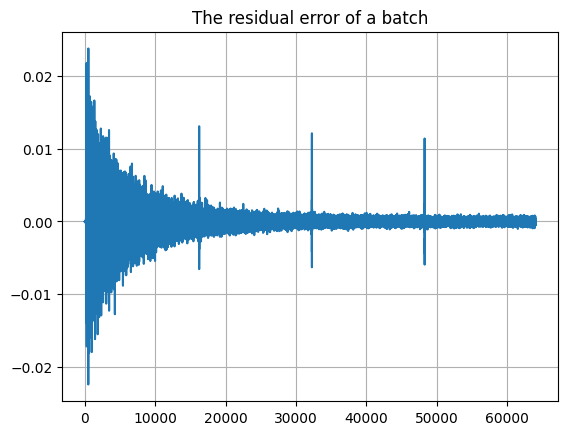

[========================================================================] 100%


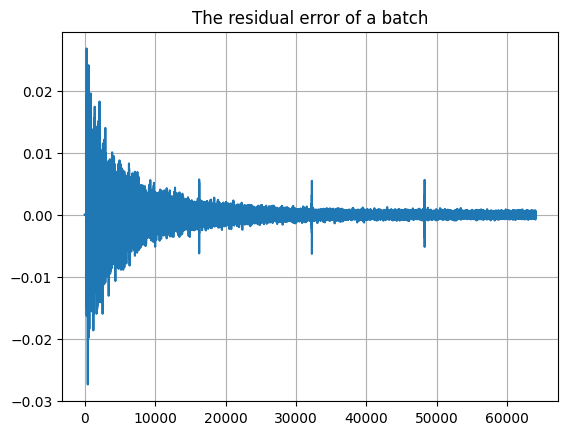

[========================================================================] 100%


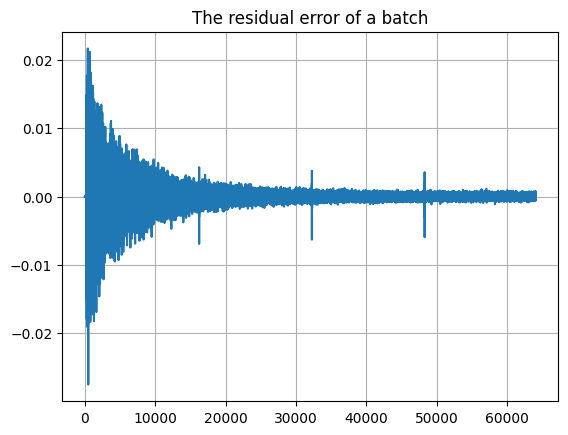

[========================================================================] 100%


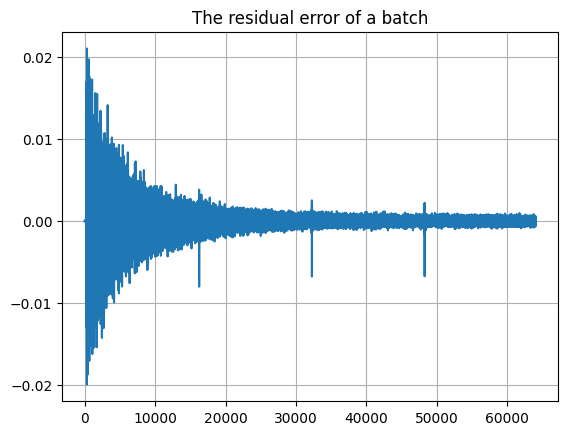

[========================================================================] 100%


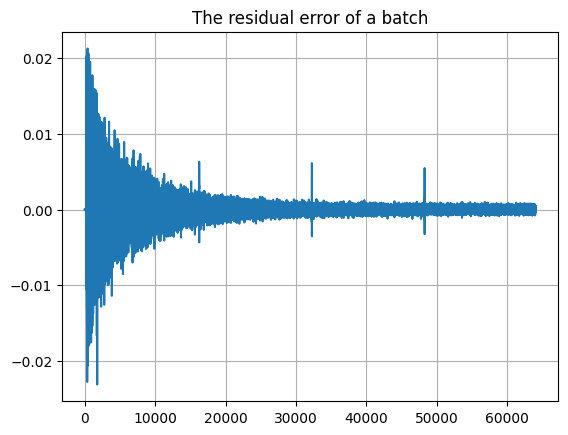

[========================================================================] 100%


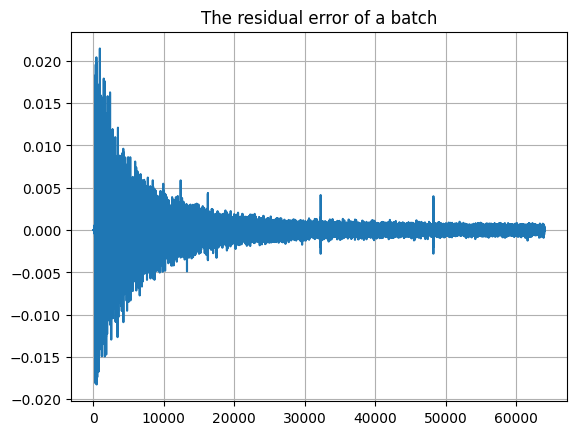

[========================================================================] 100%


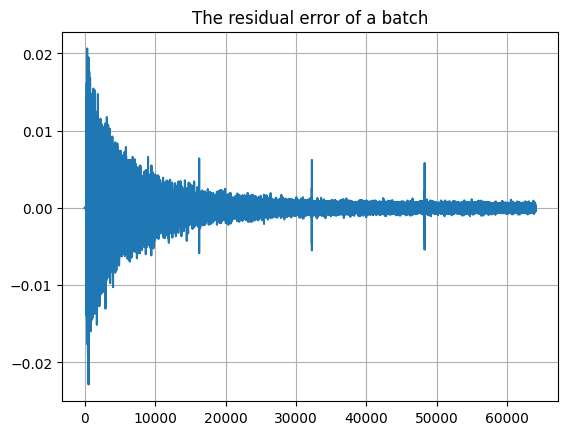

[========================================================================] 100%


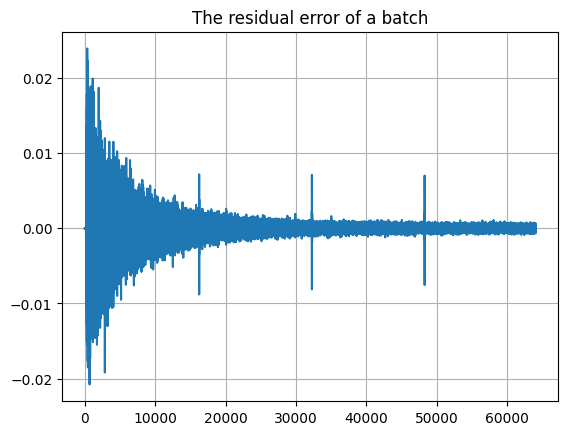

[========================================================================] 100%


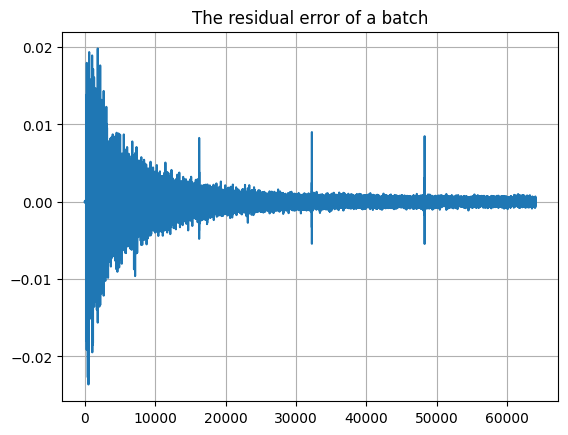

[========================================================================] 100%


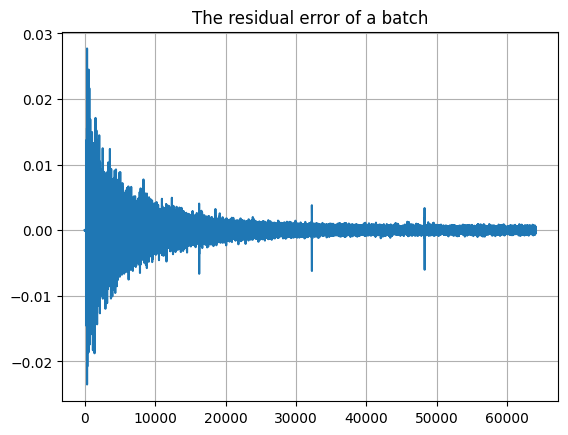

[========================================================================] 100%


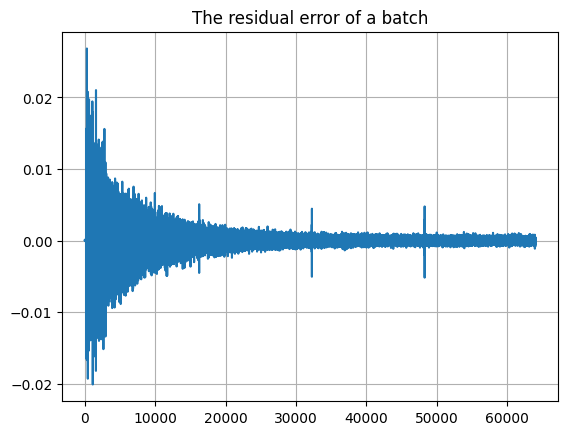

[========================================================================] 100%


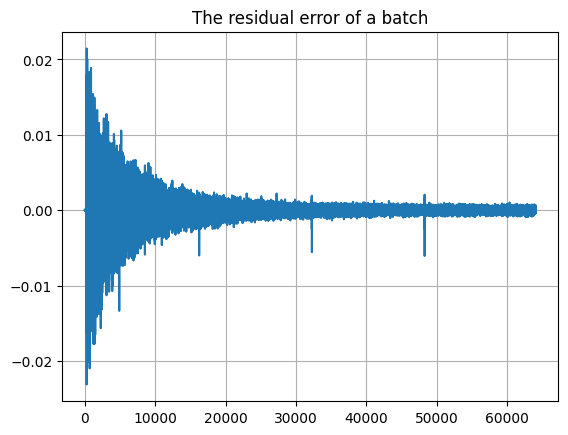

[========================================================================] 100%


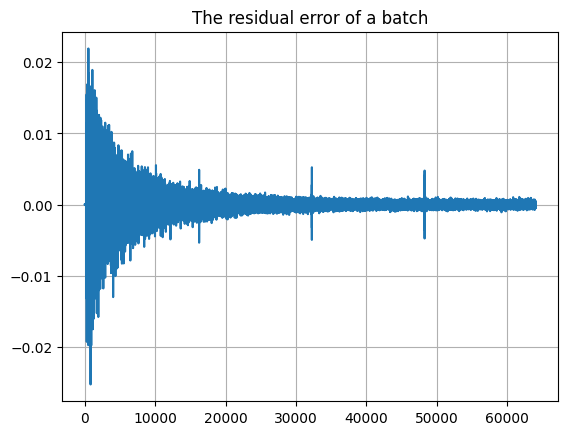

[========================================================================] 100%


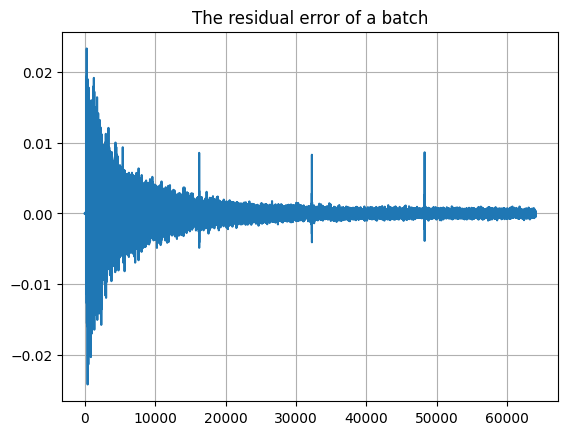

[========================================================================] 100%


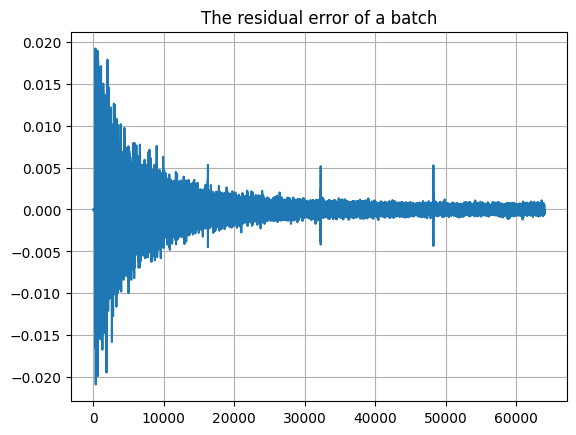

[========================================================================] 100%


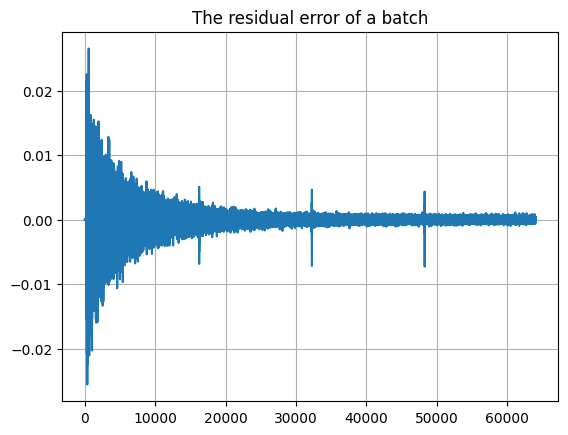

[========================================================================] 100%


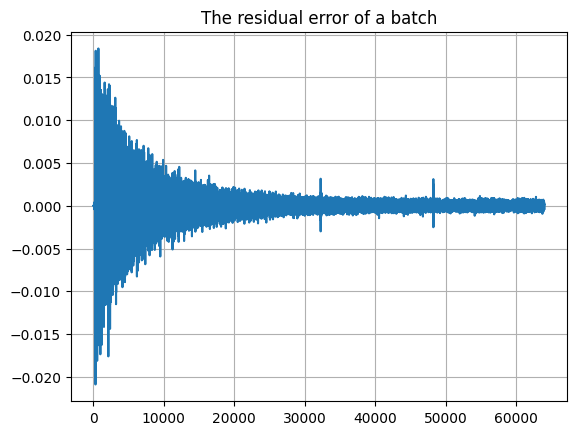

[========================================================================] 100%


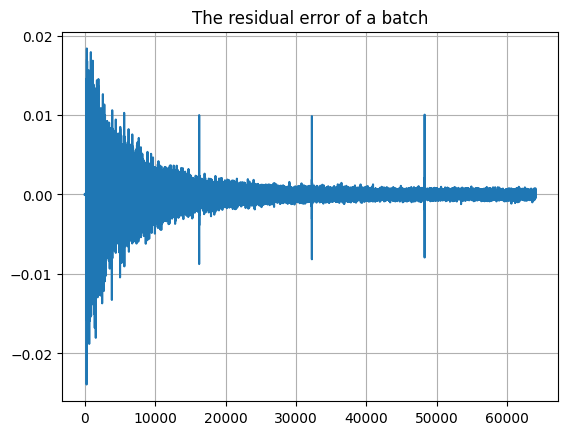

[========================================================================] 100%


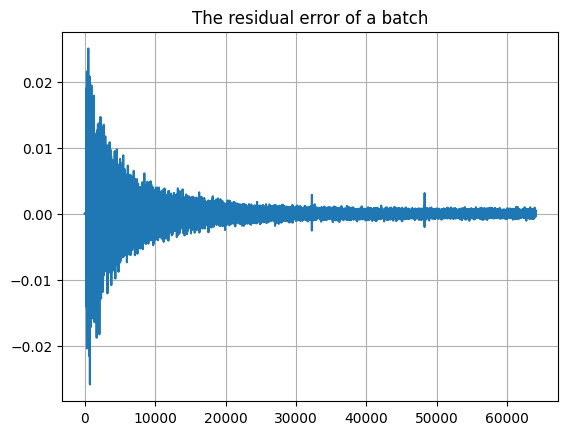

[========================================================================] 100%


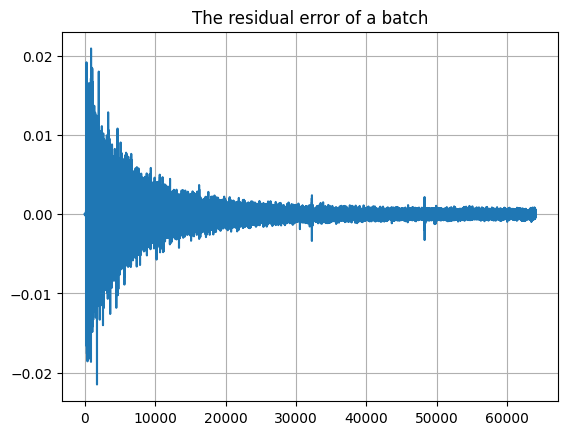

[========================================================================] 100%


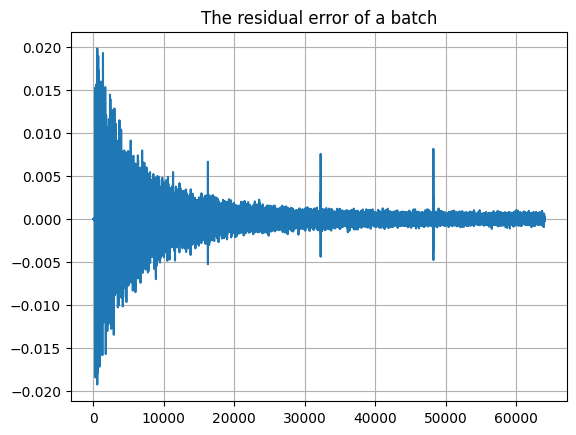

[========================================================================] 100%


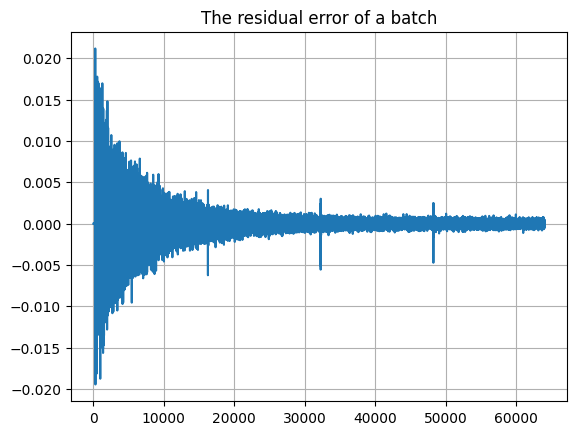

[========================================================================] 100%


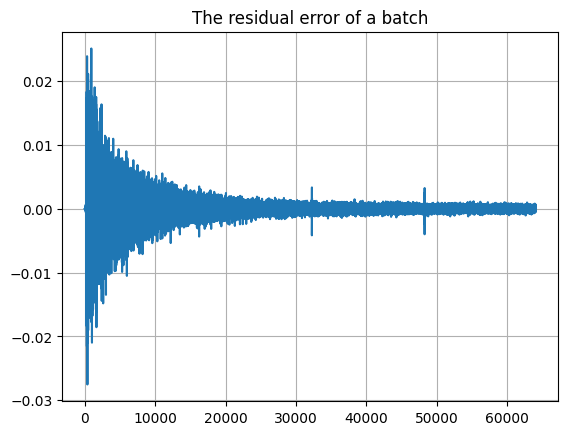

[========================================================================] 100%


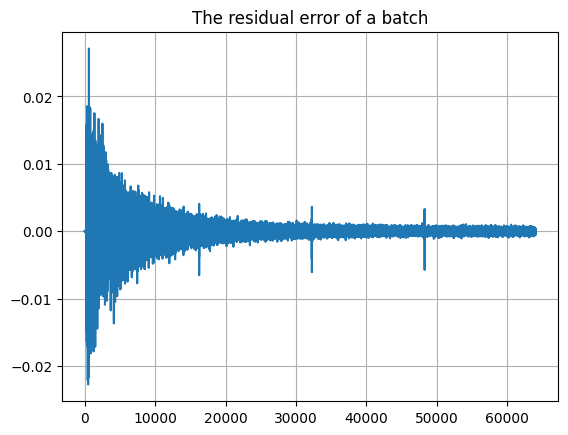

[========================================================================] 100%


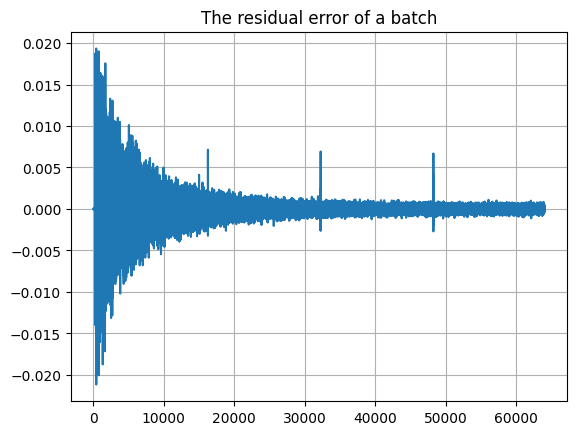

[========================================================================] 100%


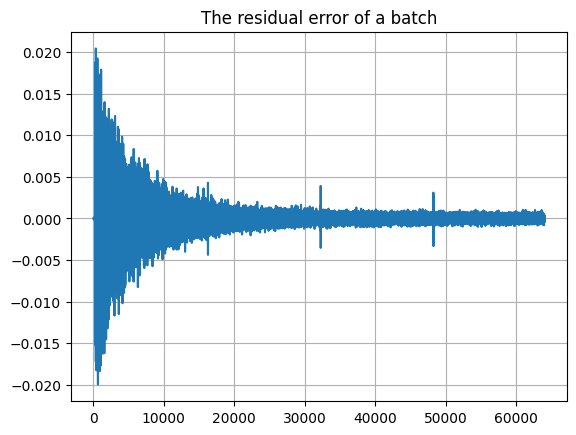

[========================================================================] 100%


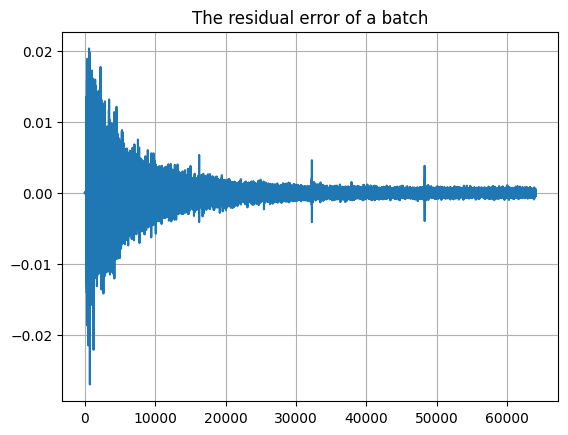

[========================================================================] 100%


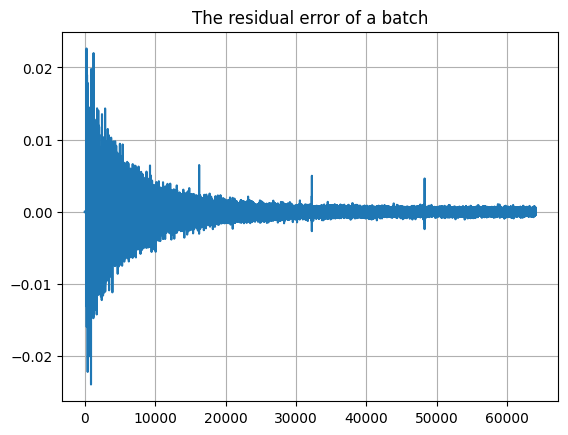

[========================================================================] 100%


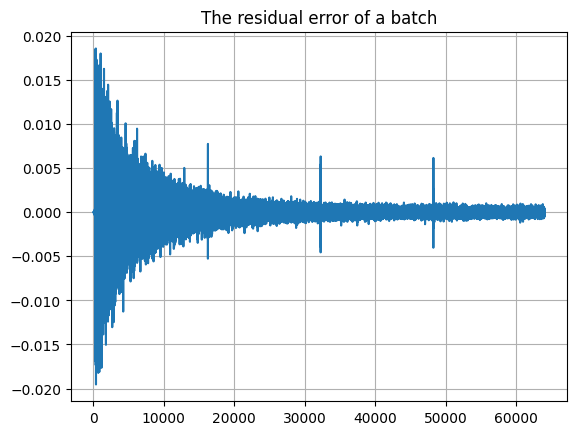

[========================================================================] 100%


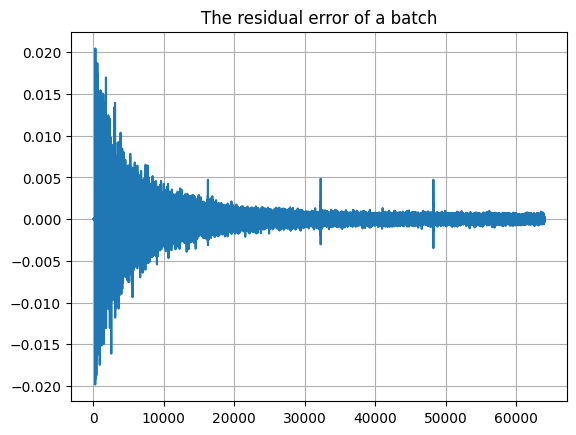

[========================================================================] 100%


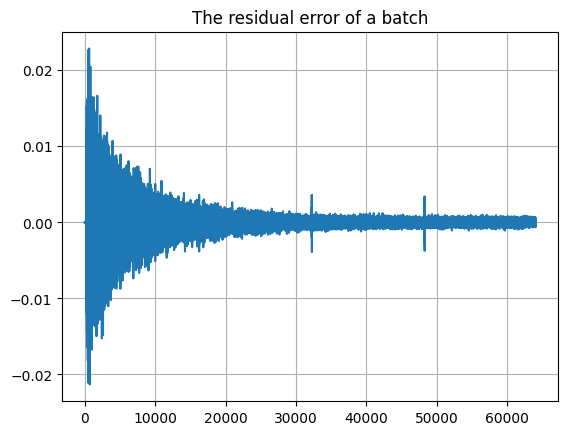

[========================================================================] 100%


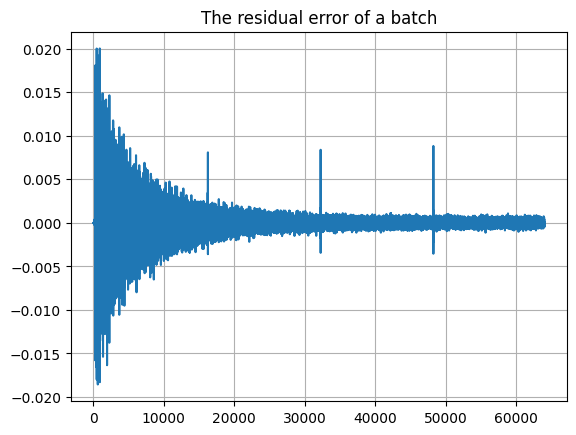

[========================================================================] 100%


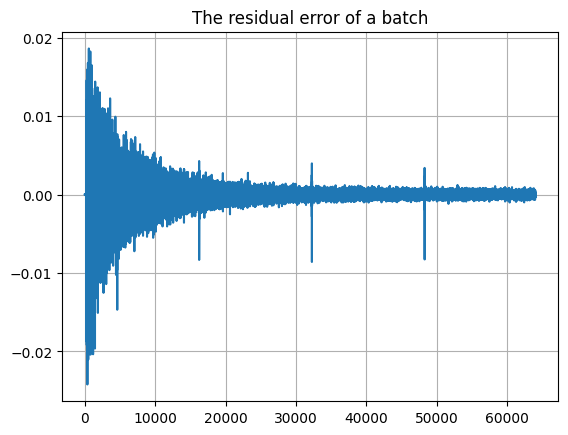

[========================================================================] 100%


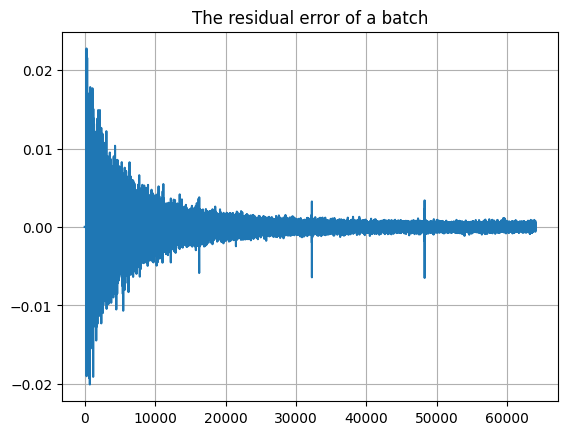

[========================================================================] 100%


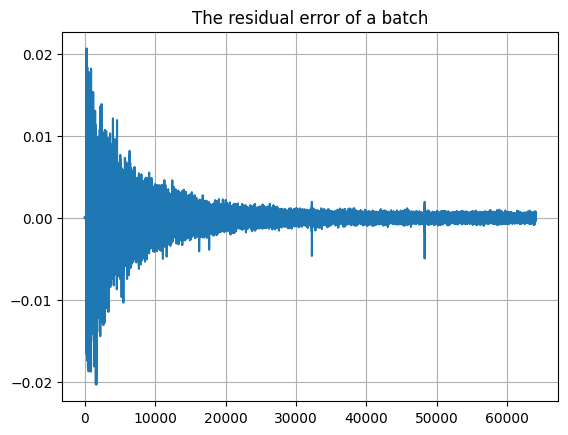

[========================================================================] 100%


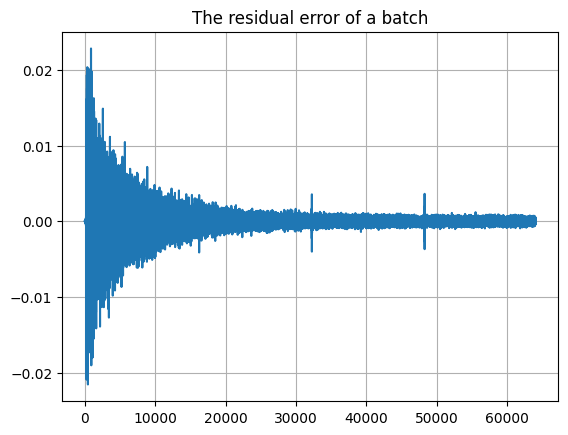

[========================================================================] 100%


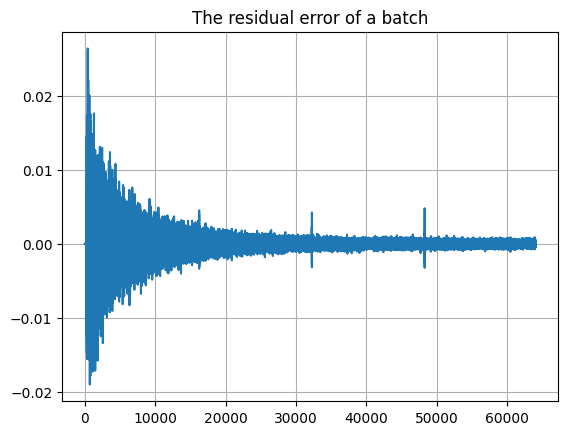

[========================================================================] 100%


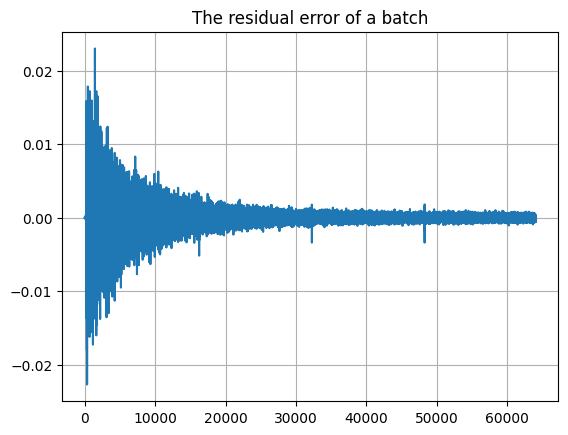

[========================================================================] 100%


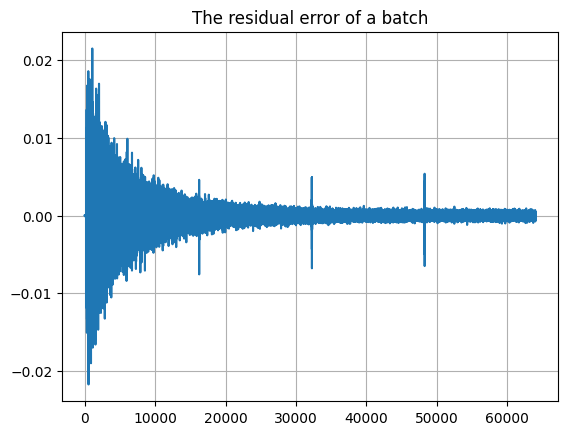

[========================================================================] 100%


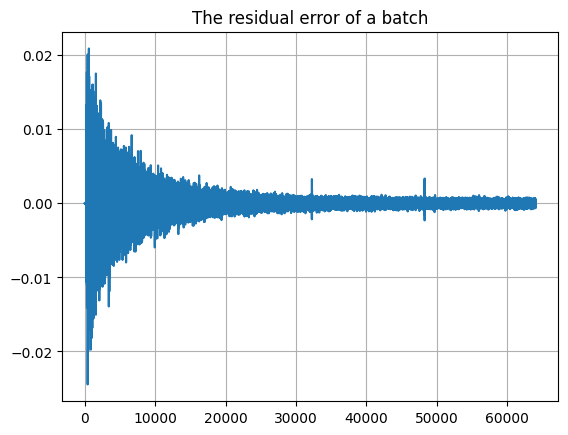

[========================================================================] 100%


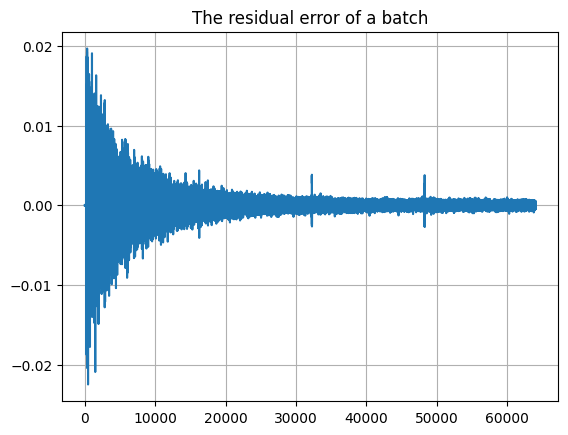

[========================================================================] 100%


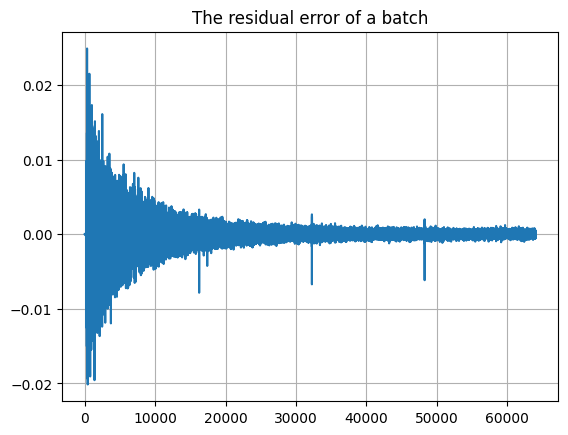

[========================================================================] 100%


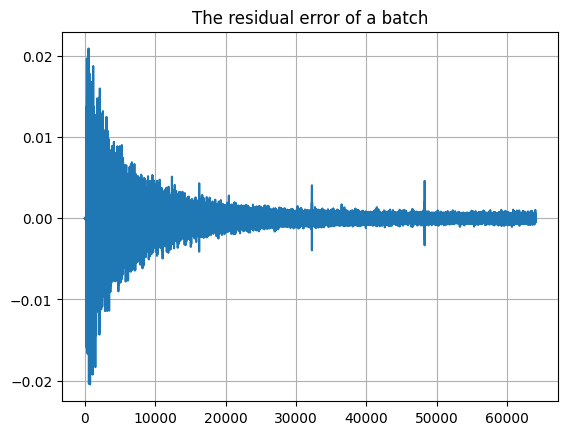

[========================================================================] 100%


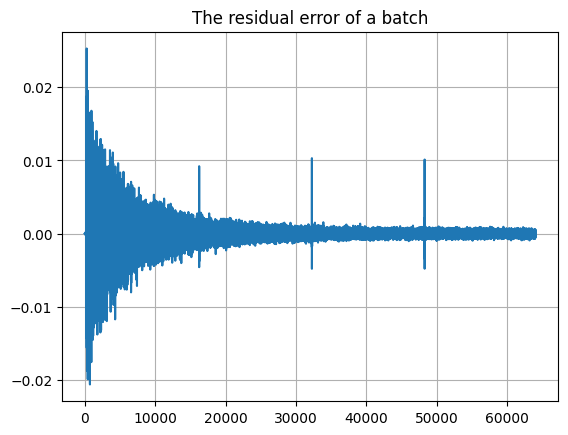

[========================================================================] 100%


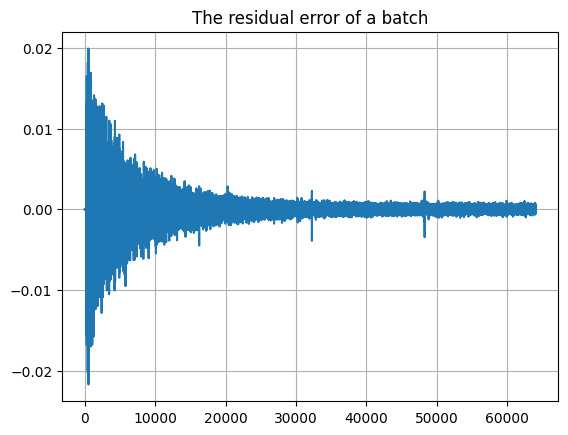

[========================================================================] 100%


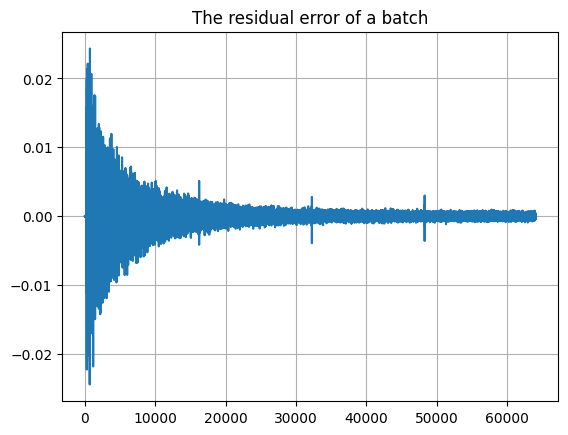

[========================================================================] 100%


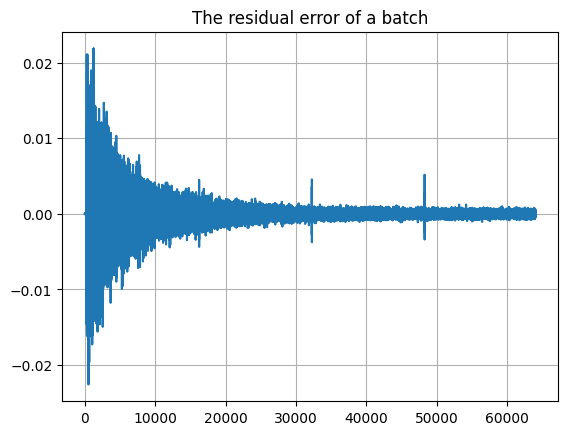

[========================================================================] 100%


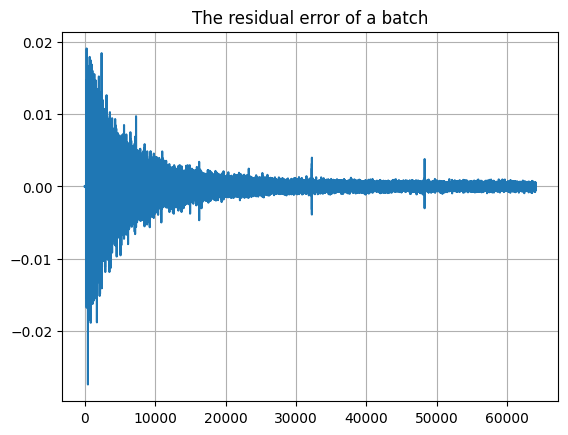

[========================================================================] 100%


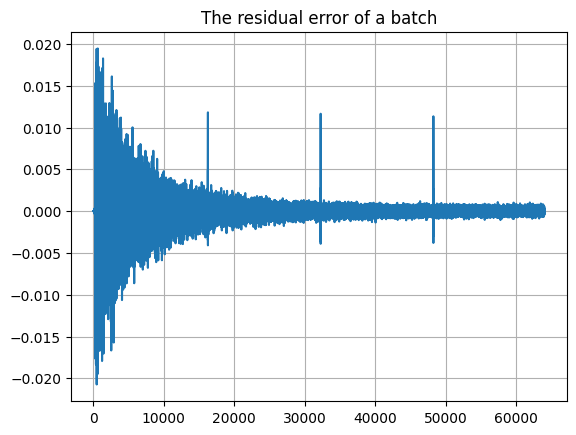

[========================================================================] 100%


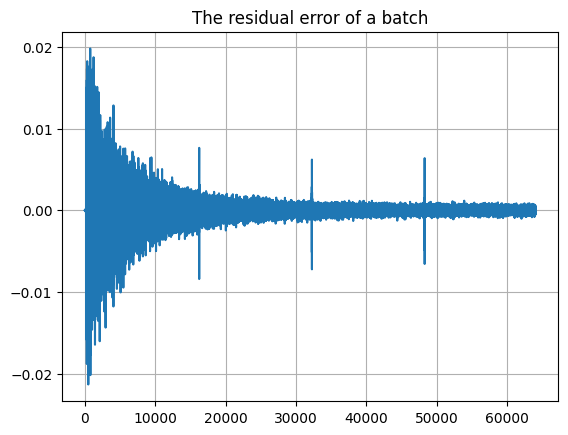

[========================================================================] 100%


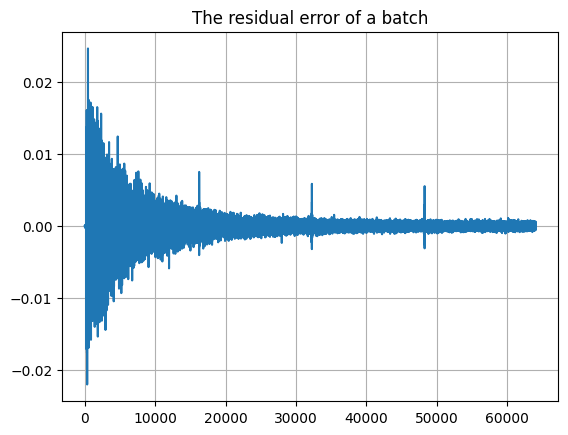

[========================================================================] 100%


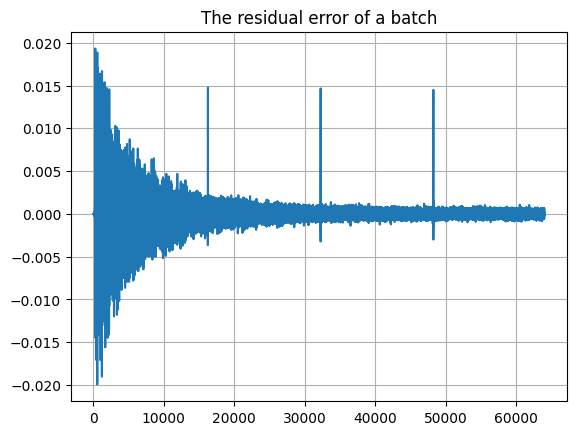

[========================================================================] 100%


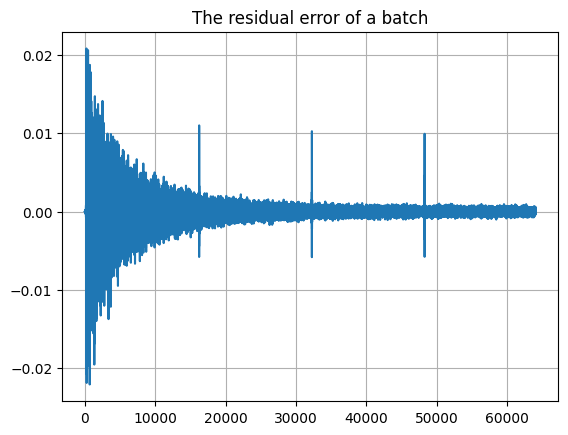

[========================================================================] 100%


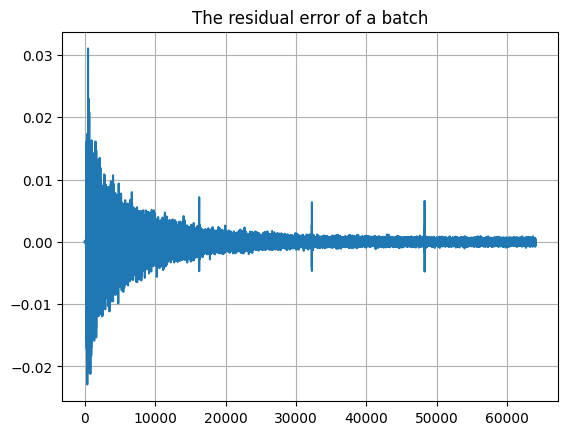

[========================================================================] 100%


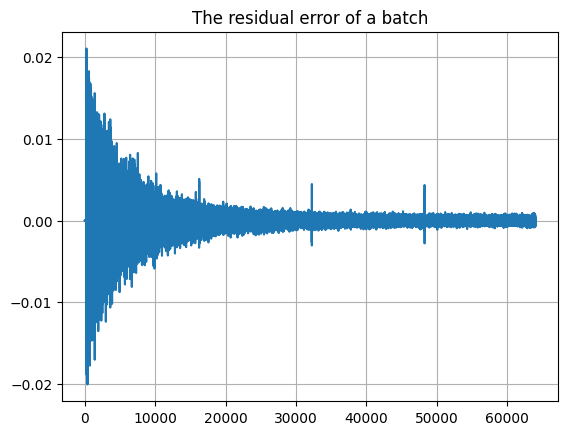

[========================================================================] 100%


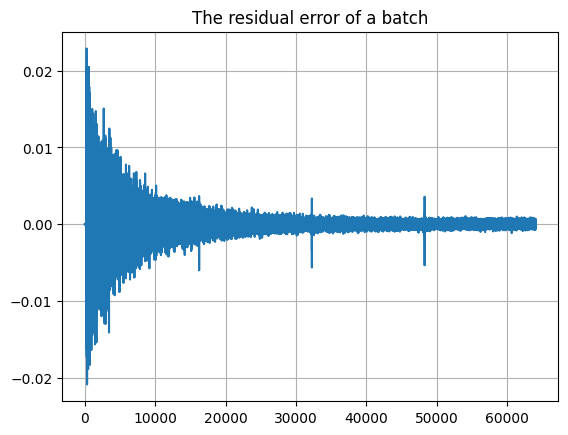

[========================================================================] 100%


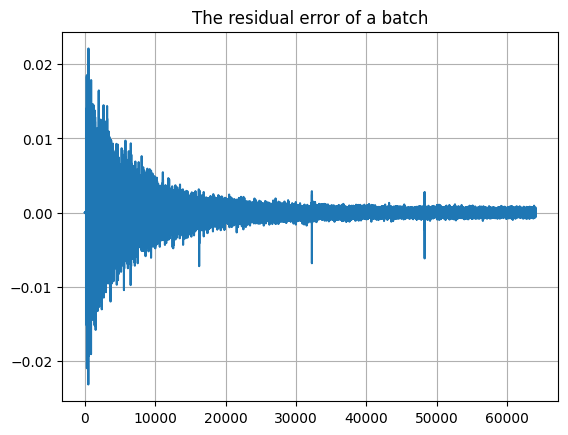

[========================================================================] 100%


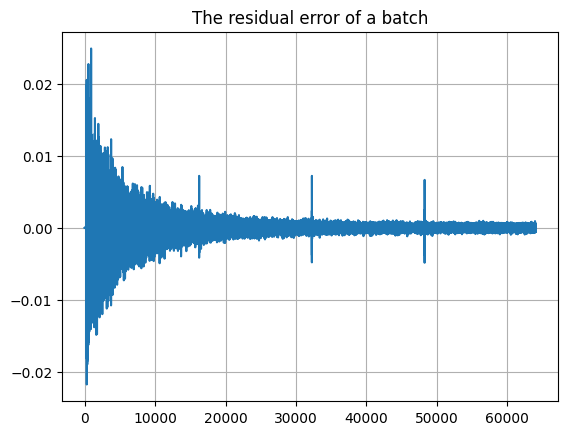

[========================================================================] 100%


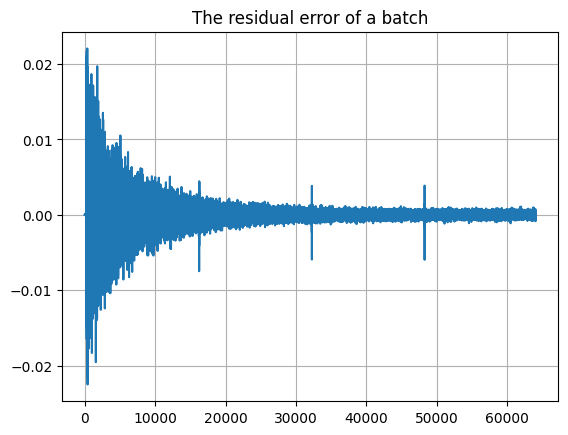

[========================================================================] 100%


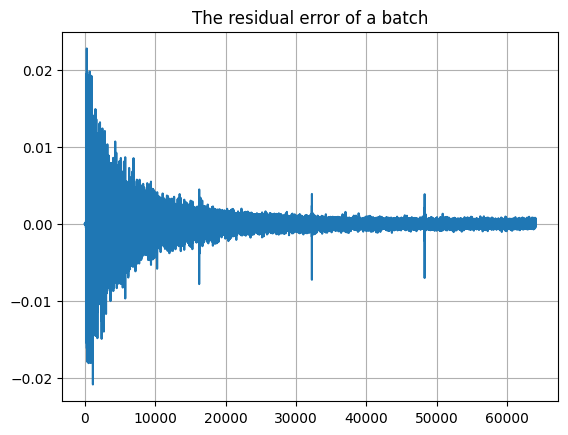

[========================================================================] 100%


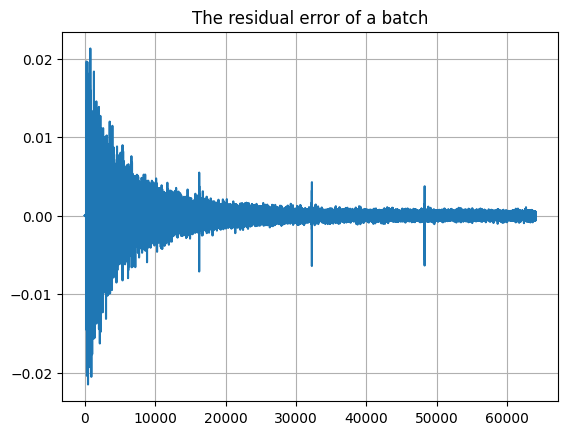

[========================================================================] 100%


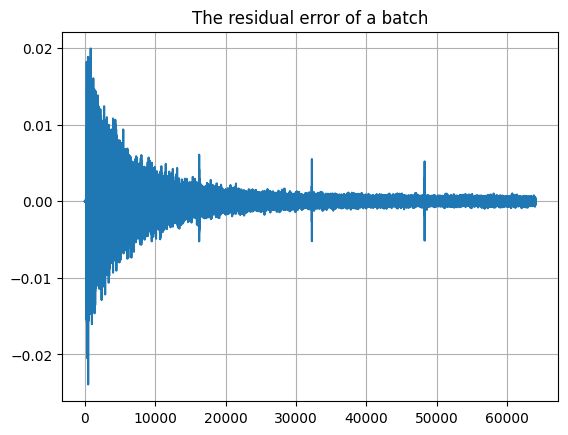

[========================================================================] 100%


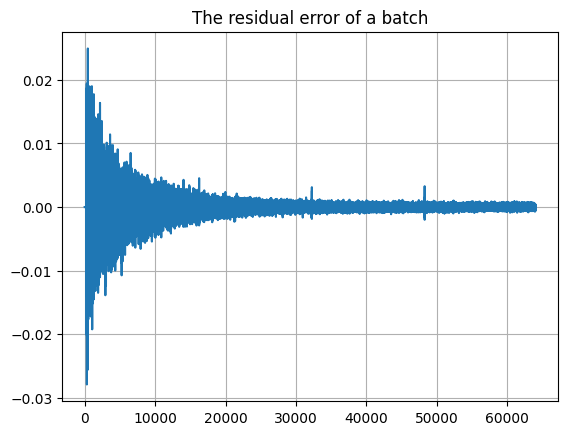

[========================================================================] 100%


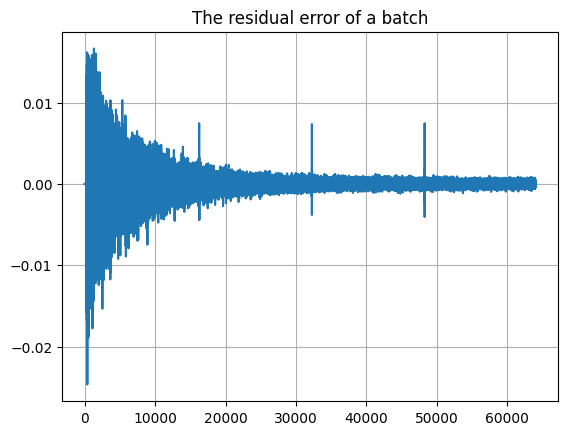

[========================================================================] 100%


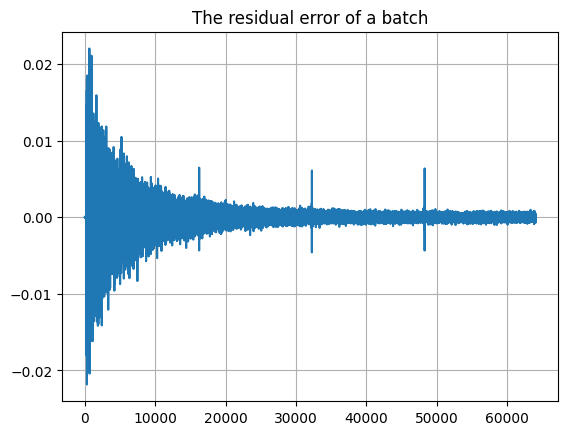

[========================================================================] 100%


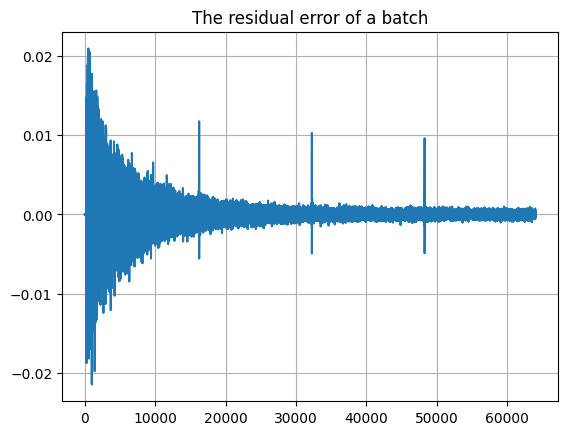

[========================================================================] 100%


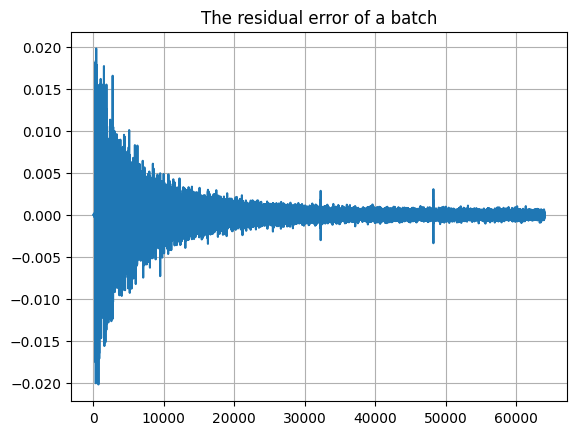

[========================================================================] 100%


=======================End labeling ============================
folder exists
=====================Start labeling ============================
The total file numer is 2000
<<===This program used cuda====>>


[========================================================================] 100%


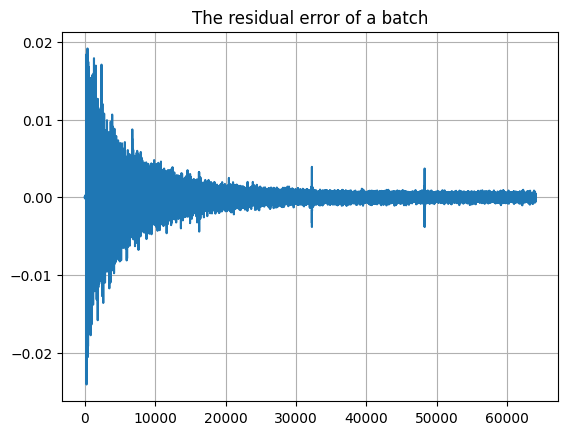

[========================================================================] 100%


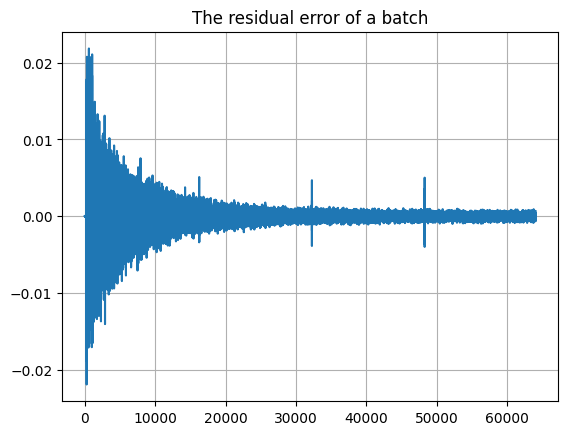

[========================================================================] 100%


=======================End labeling ============================
folder exists
=====================Start labeling ============================
The total file numer is 2000
<<===This program used cuda====>>


[========================================================================] 100%


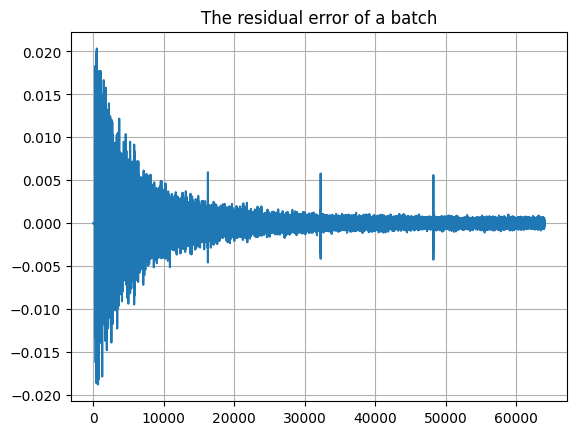

[========================================================================] 100%


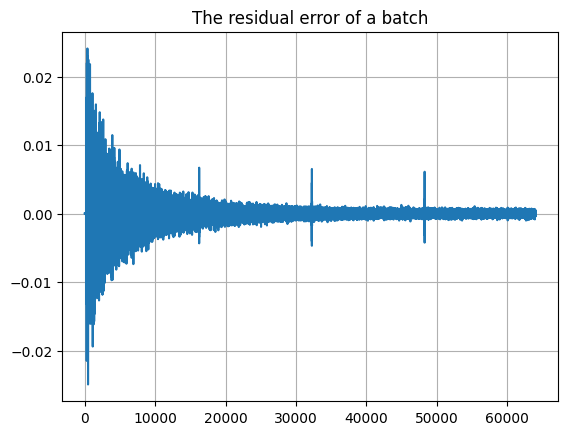

=======================End labeling ============================


[========================================================================] 100%


In [ ]:
# by batch (batch=1000, step_size=0.001, SNR=30)
# Hard Label noise dataset using the 15 pre-trained sub filters
from Automatic_Hard_Label_Subfilters_batch_v1 import Automatic_label

path_mat = 'models/Pretrained_Sub_Control_filters.mat'
datas = ["Training_data", "Testing_data", "Validate_data"]
for i in datas:
    folder_path = "Dataset/Synthesized_Dataset/" + i
    Labeler = Automatic_label(sufix='.wav', folder_path=folder_path, path_mat=path_mat, Index_file='Hard_Index.csv', threshold=0.5)
    Labeler.label()

In [ ]:

# by batch (batch=1000, step_size=0.001, SNR=30)
# Soft Label noise dataset using the 15 pre-trained sub filters
from Automatic_Soft_Label_Subfilters_batch import Automatic_label

path_mat = 'models/Pretrained_Sub_Control_filters.mat'

Labeler = Automatic_label(sufix='.wav', folder_path='Dataset/Synthesized_Dataset/Training_data', path_mat=path_mat, Index_file='Soft_Index.csv')
Labeler.label()

In [1]:
import sys

sys.dont_write_bytecode = True #不生成pychache文件，要放在导入模块前才生效

import os

# import soundfile

fs = 16000

In [7]:
run Pretraining_sub_control_filters.py

125.33052382585865
107.63134579389666
111.97704386597505
60.729184245201154
17.521039352785724


In [ ]:
# by batch (batch=1000, step_size=0.001, SNR=30)
# Hard Label noise dataset using the 15 pre-trained sub filters
from Automatic_Hard_Label_Subfilters_batch_v1 import My_Automatic_label

delays = [-50, 0, ]
path_mat = 'models/Pretrained_Sub_Control_filters.mat'
datas = ["Training_data", "Testing_data", "Validate_data"]
for delay in delays:
    path_mat = "models/Pretrained_Sub_Control_filters_delay_" + str(delay) + ".mat"
    Index_file='Hard_Index_delay_' + str(delay) + '.csv'
    batch_size = 1000
    path_folder = "Pz and Sz"
    path_subfolder = "Secondary_path_delay_" + str(delay) + "samples"
    Pri_path_file = "Primary_path.mat"
    Sec_path_file = "Secondary_path.mat"

    for i in datas:
        folder_path = "../2.Training_1DNetwork_Code/Original_Dataset/Synthesized_Dataset/" + i
        Labeler = My_Automatic_label(sufix='.wav', folder_path=folder_path, path_mat=path_mat, Index_file=Index_file, threshold=0.5, batch_size=batch_size, path_folder=path_folder, path_subfolder=path_subfolder, Pri_path_file=Pri_path_file, Sec_path_file=Sec_path_file)
        Labeler.label()

folder exists
===================== Start labeling =====================
The total file number is 80000
<<=== This program uses cuda ===>>


[========================================================================] 100%
[========================================================================] 100%
[========================================================================] 100%
[========================================================================] 100%
[========================================================================] 100%
[========================================================================] 100%
[========================================================================] 100%
[========================================================================] 100%
[========================================================================] 100%
[========================================================================] 100%
[========================================================================] 100%
[========================================================================] 100%
[=======================================

====================== End labeling ======================
folder exists
===================== Start labeling =====================
The total file number is 2000
<<=== This program uses cuda ===>>


[========================================================================] 100%
[========================================================================] 100%
[========================================================================] 100%


====================== End labeling ======================
folder exists
===================== Start labeling =====================
The total file number is 2000
<<=== This program uses cuda ===>>


[========================================================================] 100%
[========================================================================] 100%
[========================================================================] 100%


====================== End labeling ======================
folder exists
===================== Start labeling =====================
The total file number is 80000
<<=== This program uses cuda ===>>


[========================================================================] 100%
[========================================================================] 100%
[========================================================================] 100%
[========================================================================] 100%
[========================================================================] 100%
[========================================================================] 100%
[========================================================================] 100%
[========================================================================] 100%
[========================================================================] 100%
[========================================================================] 100%
[========================================================================] 100%
[========================================================================] 100%
[=======================================